In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

pd.set_option("display.float_format", lambda value: f"{value:.6f}")

# 1. Select the portfolio

This notebook builds a minimum-variance portfolio from historical market data.

Enter ticker symbols separated by commas, for example `AAPL,MSFT`. If the input is blank, the notebook uses this fixed set of widely followed large-cap companies:

`AAPL`, `MSFT`, `GOOGL`, `AMZN`, `NVDA`, and `JPM`.

Using a fixed default portfolio makes results easier to reproduce and discuss. The portfolio will contain one weight $w_i$ for each selected asset. The weights will later be constrained so that the portfolio is fully invested and long-only:

$$
\sum_{i=1}^{n} w_i=1, \qquad 0\leq w_i\leq1
$$

In [2]:
user_input = input("Enter ticker symbols (comma-separated), or press Enter for the fixed default portfolio: ")

if user_input.strip():
    tickers = [ticker.strip().upper() for ticker in user_input.split(",") if ticker.strip()]
else:
    tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "JPM"]

if len(tickers) < 2:
    raise ValueError("Please provide at least two ticker symbols.")

print(f"Selected assets ({len(tickers)}): {', '.join(tickers)}")

Selected assets (6): AAPL, MSFT, GOOGL, AMZN, NVDA, JPM


# 2. Download and inspect historical prices

Prices are downloaded from Yahoo Finance with `auto_adjust=True`. This uses adjusted prices, which account for stock splits and distributions more appropriately than raw closing prices.

The single download is split into training and test price partitions immediately. Asset eligibility and complete-case date alignment are determined from the training partition only, so neither can depend on 2026 observations.

The download includes history through the latest available date. Prices before `2026-01-01` form the training partition; prices from that date onward form the held-out test partition. The final training close is retained only as the known starting price required to calculate the first test return.

In [3]:
start_date = "2018-01-01"
optimization_cutoff = pd.Timestamp("2026-01-01")
end_date = (pd.Timestamp.today().normalize() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

downloaded_prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    group_by="column",
)["Close"]

if isinstance(downloaded_prices, pd.Series):
    downloaded_prices = downloaded_prices.to_frame(name=tickers[0])

# Split immediately after the single download.  The training partition alone
# determines the eligible assets and its complete-case observations.
training_prices = downloaded_prices.loc[
    downloaded_prices.index < optimization_cutoff
].copy()
training_prices = training_prices.dropna(axis=1, how="all").dropna()
tickers = training_prices.columns.tolist()

if len(tickers) < 2:
    raise ValueError("Fewer than two tickers returned usable training data.")
if training_prices.empty:
    raise ValueError("No complete training price observations are available before 2026.")

# This is a separate test partition.  The final training close is added later
# only as the known starting price for the first out-of-sample return.
test_prices = downloaded_prices.loc[
    downloaded_prices.index >= optimization_cutoff, tickers
].dropna().copy()

print(f"Training price observations: {training_prices.shape[0]} trading days")
print(f"Test price observations: {test_prices.shape[0]} trading days")
print(f"Assets selected from training data: {', '.join(tickers)}")
display(training_prices.head())

Training price observations: 2011 trading days
Test price observations: 161 trading days
Assets selected from training data: AAPL, AMZN, GOOGL, JPM, MSFT, NVDA


Ticker,AAPL,AMZN,GOOGL,JPM,MSFT,NVDA
Date,,,,,,
2018-01-02,40.232388,59.450500,53.188862,85.516022,78.552032,4.922529
2018-01-03,40.225361,60.209999,54.096310,85.603172,78.917618,5.246500
2018-01-04,40.412212,60.479500,54.306450,86.829498,79.612175,5.274157
2018-01-05,40.872322,61.457001,55.026566,86.272057,80.599243,5.318850
2018-01-08,40.720516,62.343498,55.220848,86.399483,80.681503,5.481823


# 3. Convert prices to returns

Price levels are not directly comparable across assets and are usually non-stationary. Returns measure the percentage change from one trading day to the next:

$$
r_{t,i}=\frac{P_{t,i}}{P_{t-1,i}}-1
$$

The portfolio return on a day is the weighted sum of asset returns:

$$
r_{p,t}=w^T r_t
$$

Returns are calculated separately from the price partitions. Pre-2026 returns estimate the covariance matrix and optimized weights; the 2026 returns are reserved for testing. The descriptive statistics shown here use the optimization returns only. This time-based split prevents future information from influencing the weights.

The sample mean is removed before covariance is computed. This is called **centering**. Centering is different from standardizing: centering changes the mean to zero, while standardizing also divides by the standard deviation.

In [4]:
optimization_returns = training_prices.pct_change().dropna()

# Add the last known training close solely to bridge into the first test return.
backtest_prices = pd.concat([training_prices.tail(1), test_prices])
backtest_returns = backtest_prices.pct_change().iloc[1:]

if optimization_returns.empty:
    raise ValueError("No optimization returns are available before 1 January 2026.")
if backtest_returns.empty:
    raise ValueError("No test return observations are available from 1 January 2026 onward.")

print(f"Optimization return observations: {optimization_returns.shape[0]}")
display(optimization_returns.describe().T[["mean", "std", "min", "max"]])

Optimization return observations: 2010


,mean,std,min,max
Ticker,,,,
AAPL,0.001137,0.019397,-0.128647,0.153288
AMZN,0.000910,0.021675,-0.140494,0.135359
GOOGL,0.001072,0.019518,-0.116341,0.102244
JPM,0.000820,0.018293,-0.149649,0.180125
MSFT,0.001061,0.017857,-0.147390,0.142169
NVDA,0.002330,0.032310,-0.187558,0.243696


# 4. Covariance and correlation matrices

For centered returns, the covariance between assets $i$ and $j$ is:

$$
\operatorname{Cov}(r_i,r_j)=\frac{1}{T-1}\sum_{t=1}^{T}(r_{t,i}-\bar r_i)(r_{t,j}-\bar r_j)
$$

The covariance matrix $\Sigma$ contains these values. Its diagonal contains each asset's variance, so it preserves the original risk scale. The portfolio variance is therefore:

$$
\operatorname{Var}(r_p)=w^T\Sigma w
$$

In this notebook, $\Sigma$ and the correlation matrix are estimated only from `optimization_returns`, which contains observations before `2026-01-01`. This keeps 2026 data out of the optimized weights.

Correlation is covariance after dividing by both standard deviations:

$$
\operatorname{Corr}(r_i,r_j)=\frac{\operatorname{Cov}(r_i,r_j)}{\sigma_i\sigma_j}
$$

**Which matrix should be used?** Use the covariance matrix for optimizing the actual portfolio variance. Use standardized returns and the correlation matrix for relationship-focused PCA, where every asset starts with variance one. Standardizing is useful for comparison, but replacing covariance with correlation in the risk objective would ignore differences in asset volatility.

In [5]:
centered_returns = optimization_returns - optimization_returns.mean()
covariance_matrix = centered_returns.cov()
correlation_matrix = centered_returns.corr()

scaler = StandardScaler(with_mean=True, with_std=True)
standardized_returns = pd.DataFrame(
    scaler.fit_transform(optimization_returns),
    index=optimization_returns.index,
    columns=optimization_returns.columns,
)

print(
    f"Optimization sample: {optimization_returns.index[0].date()} "
    f"to {optimization_returns.index[-1].date()} "
    f"({optimization_returns.shape[0]} trading days)"
)
print("Covariance matrix:")
display(covariance_matrix)
print("Correlation matrix:")
display(correlation_matrix)

Optimization sample: 2018-01-03 to 2025-12-31 (2010 trading days)
Covariance matrix:


Ticker,AAPL,AMZN,GOOGL,JPM,MSFT,NVDA
Ticker,,,,,,
AAPL,0.000376,0.000250,0.000236,0.000153,0.000243,0.000359
AMZN,0.000250,0.000470,0.000271,0.000129,0.000264,0.000409
GOOGL,0.000236,0.000271,0.000381,0.000150,0.000247,0.000363
JPM,0.000153,0.000129,0.000150,0.000335,0.000145,0.000213
MSFT,0.000243,0.000264,0.000247,0.000145,0.000319,0.000382
NVDA,0.000359,0.000409,0.000363,0.000213,0.000382,0.001044


Correlation matrix:


Ticker,AAPL,AMZN,GOOGL,JPM,MSFT,NVDA
Ticker,,,,,,
AAPL,1.000000,0.595128,0.622444,0.430892,0.700324,0.572117
AMZN,0.595128,1.000000,0.641367,0.324693,0.682106,0.583937
GOOGL,0.622444,0.641367,1.000000,0.419461,0.708788,0.575811
JPM,0.430892,0.324693,0.419461,1.000000,0.443988,0.359924
MSFT,0.700324,0.682106,0.708788,0.443988,1.000000,0.661564
NVDA,0.572117,0.583937,0.575811,0.359924,0.661564,1.000000


# 5. PCA: eigenvalues and eigenvectors

PCA is an eigenvalue decomposition of a covariance-like matrix. For a matrix $A$:

$$
Av_k=\lambda_kv_k
$$

Here, $v_k$ is the $k$th eigenvector and $\lambda_k$ is its eigenvalue. Each eigenvector is a portfolio-shaped direction: its entries show how strongly each asset contributes to that component. The corresponding eigenvalue measures the variation captured in that direction.

This notebook performs two valid but different analyses:

- **Covariance PCA:** uses the original return scale. Assets with larger volatility can contribute more to the dominant components. It describes actual dollar-return risk structure.
- **Correlation PCA:** uses standardized returns. Every asset has mean zero and standard deviation one, so the components emphasize co-movement relationships rather than volatility differences.

Eigenvector signs are arbitrary: multiplying an eigenvector by $-1$ describes the same component. PCA is diagnostic here; it helps us understand the structure but does not directly produce the minimum-variance weights.

In [6]:
covariance_eigenvalues, covariance_eigenvectors = np.linalg.eigh(covariance_matrix)
correlation_eigenvalues, correlation_eigenvectors = np.linalg.eigh(correlation_matrix)

covariance_order = np.argsort(covariance_eigenvalues)[::-1]
correlation_order = np.argsort(correlation_eigenvalues)[::-1]

covariance_eigenvalues = covariance_eigenvalues[covariance_order]
covariance_eigenvectors = covariance_eigenvectors[:, covariance_order]
correlation_eigenvalues = correlation_eigenvalues[correlation_order]
correlation_eigenvectors = correlation_eigenvectors[:, correlation_order]

covariance_pca = pd.DataFrame(
    {
        "eigenvalue": covariance_eigenvalues,
        "explained_variance_ratio": covariance_eigenvalues / covariance_eigenvalues.sum(),
    },
    index=[f"PC{i}" for i in range(1, len(tickers) + 1)],
)
correlation_pca = pd.DataFrame(
    {
        "eigenvalue": correlation_eigenvalues,
        "explained_variance_ratio": correlation_eigenvalues / correlation_eigenvalues.sum(),
    },
    index=[f"PC{i}" for i in range(1, len(tickers) + 1)],
)

print("Covariance PCA:")
display(covariance_pca)
print("Covariance PCA eigenvectors (columns):")
display(pd.DataFrame(covariance_eigenvectors, index=tickers))

print("Correlation PCA:")
display(correlation_pca)
print("Correlation PCA eigenvectors (columns):")
display(pd.DataFrame(correlation_eigenvectors, index=tickers))

Covariance PCA:


,eigenvalue,explained_variance_ratio
PC1,0.001933,0.660850
PC2,0.000355,0.121347
PC3,0.000255,0.087248
PC4,0.000158,0.054194
PC5,0.000139,0.047381
PC6,0.000085,0.028980


Covariance PCA eigenvectors (columns):


,0,1,2,3,4,5
AAPL,-0.343851,0.306568,0.003085,0.697871,-0.466121,-0.288929
AMZN,-0.390720,0.298333,-0.523773,-0.597528,-0.329333,-0.136004
GOOGL,-0.351557,0.326385,-0.118300,0.111541,0.814887,-0.281787
JPM,-0.216904,0.365764,0.830621,-0.346392,-0.086569,-0.041909
MSFT,-0.345643,0.200401,-0.065258,0.149588,0.052083,0.900568
NVDA,-0.662567,-0.732491,0.132165,-0.033629,0.004903,-0.076419


Correlation PCA:


,eigenvalue,explained_variance_ratio
PC1,3.820764,0.636794
PC2,0.740865,0.123477
PC3,0.443779,0.073963
PC4,0.395895,0.065983
PC5,0.347317,0.057886
PC6,0.251381,0.041897


Correlation PCA eigenvectors (columns):


,0,1,2,3,4,5
AAPL,-0.423933,-0.005979,-0.216320,0.811294,-0.176648,-0.289912
AMZN,-0.415955,-0.304879,-0.252525,-0.482587,-0.642699,-0.155917
GOOGL,-0.430079,-0.077923,-0.358161,-0.265920,0.725725,-0.288603
JPM,-0.300091,0.927046,0.052880,-0.174468,-0.128050,-0.029970
MSFT,-0.456163,-0.090803,-0.038524,0.081424,0.079528,0.877059
NVDA,-0.405162,-0.182431,0.869987,-0.033616,0.079600,-0.195498


# 6. Check the quadratic objective

A general multivariate quadratic function can be written as:

$$
f(x)=x^TCx+b^Tx+d
$$

Its gradient and Hessian are:

$$
\nabla f(x)=2Cx+b, \qquad \nabla^2f(x)=2C
$$

The unconstrained critical point satisfies:

$$
2Cx+b=0
\quad\Longrightarrow\quad
x^*=-\frac{1}{2}C^{-1}b
$$

For this portfolio problem:

$$
f(w)=w^T\Sigma w, \qquad b=0, \qquad C=\Sigma
$$

Therefore the unconstrained critical point is $w=0$. It is not a valid portfolio because its weights sum to zero rather than one. The portfolio constraint changes the problem: we must minimize the quadratic over the feasible set $\mathbf{1}^Tw=1$ and, here, $w_i\geq0$.

The covariance matrix should be positive semidefinite, meaning all eigenvalues are non-negative. If all eigenvalues are strictly positive, $2\Sigma$ is positive definite, the objective is strictly convex, and any feasible optimizer solution is the unique global minimum. A tiny negative value can be floating-point error; a materially negative value signals a problem with the data or matrix construction.

In [7]:
minimum_eigenvalue = covariance_eigenvalues.min()
positive_semidefinite = minimum_eigenvalue >= -1e-12

print(f"Smallest covariance eigenvalue: {minimum_eigenvalue:.12e}")
print(f"Largest covariance eigenvalue: {covariance_eigenvalues.max():.12e}")

if not positive_semidefinite:
    raise ValueError(
        "The covariance matrix has a materially negative eigenvalue. "
        "Check the input data before optimizing."
    )

print("The covariance objective is convex for this dataset.")

Smallest covariance eigenvalue: 8.475280250456e-05
Largest covariance eigenvalue: 1.932642960944e-03
The covariance objective is convex for this dataset.


# 7. Optimize the portfolio weights

We now solve the constrained minimum-variance problem using the covariance matrix estimated from returns before `2026-01-01`:

$$
\min_w\; w^T\Sigma w
$$

subject to:

$$
\mathbf{1}^Tw=1, \qquad w_i\geq0
$$

The first constraint means all capital is invested. The second constraint makes this a long-only portfolio, so no asset can have a negative weight or exceed 100% under these bounds.

For intuition, ignore the long-only bounds and use a Lagrange multiplier:

$$
\mathcal{L}(w,\lambda)=w^T\Sigma w-\lambda(\mathbf{1}^Tw-1)
$$

The first-order condition is:

$$
2\Sigma w-\lambda\mathbf{1}=0
$$

which gives the analytical fully-invested minimum-variance weights:

$$
\boxed{w^*=\frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}^T\Sigma^{-1}\mathbf{1}}}
$$

Those analytical weights can contain negative values. The notebook uses SLSQP with bounds $0\leq w_i\leq1$ to produce the **Optimized weights** used in the 2026 test. The **Equal weights** portfolio assigns $1/n$ to every asset as a balanced benchmark. Both sets of weights are fixed throughout the out-of-sample period.

In [8]:
asset_count = len(tickers)
initial_weights = np.full(asset_count, 1 / asset_count)

covariance_values = covariance_matrix.to_numpy()

def portfolio_variance(weights):
    return float(weights @ covariance_values @ weights)

def portfolio_volatility(weights):
    return np.sqrt(portfolio_variance(weights))

constraints = [{"type": "eq", "fun": lambda weights: np.sum(weights) - 1}]
bounds = [(0, 1) for _ in tickers]

optimization_result = minimize(
    portfolio_variance,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 1000},
)

if not optimization_result.success:
    raise RuntimeError(f"Optimization failed: {optimization_result.message}")

optimized_weights = pd.Series(optimization_result.x, index=tickers, name="weight")
equal_weights = pd.Series(initial_weights, index=tickers, name="weight")

weights_comparison = pd.DataFrame({"Optimized weights": optimized_weights, "Equal weights": equal_weights})
display(weights_comparison)

,Optimized weights,Equal weights
AAPL,0.136909,0.166667
AMZN,0.079739,0.166667
GOOGL,0.121599,0.166667
JPM,0.412544,0.166667
MSFT,0.249209,0.166667
NVDA,0.000000,0.166667


# 8. Out-of-sample portfolio test

The optimized weights are estimated using only returns before `2026-01-01`. The price dataset was split immediately after download, before asset selection, cleaning, return calculation, or any fitted statistic. All 2026 returns are held out and used only to test performance.

The backtest treats 31 December 2025 as the investment date. Because 31 December and 1 January are not trading days, the first observed test return is the next available trading day. The equal-weight portfolio is a balanced benchmark with the same assets and a weight of $1/n$ per asset.

For each test day, the portfolio return is the weighted sum of the asset returns:

$$
r_{p,t}=w^T r_t
$$

Starting with an investment of 1.00, cumulative return is calculated as:

$$
V_t=\prod_{s=1}^{t}(1+r_{p,s}),
\qquad
R_t=V_t-1
$$

The line chart compares cumulative returns for the **Optimized weights** and **Equal weights** portfolios. The optimized weights remain fixed throughout 2026; there is no look-ahead reoptimization or periodic rebalancing. Prices are adjusted prices, so the test reflects splits and distributions included by Yahoo Finance.

Backtest period: 2026-01-02 to 2026-08-24
Portfolio performance from an investment of 1.00:


,total_return,ending_value_of_1
Optimized weights,0.117903,1.117903
Equal weights,0.132913,1.132913


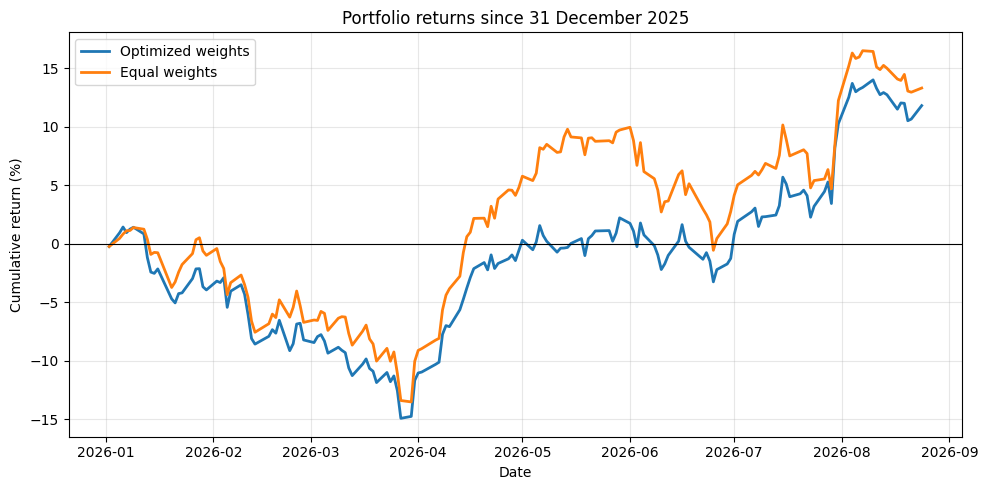

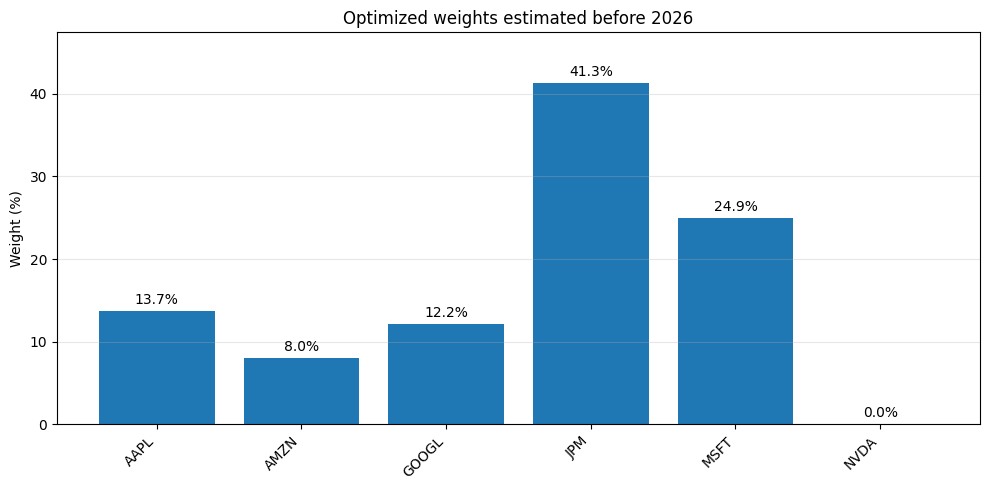

In [9]:
portfolio_daily_returns = pd.DataFrame(
    {
        "Optimized weights": backtest_returns @ optimized_weights,
        "Equal weights": backtest_returns @ equal_weights,
    }
)
cumulative_returns = (1 + portfolio_daily_returns).cumprod() - 1

backtest_summary = pd.DataFrame(
    {
        "total_return": cumulative_returns.iloc[-1],
        "ending_value_of_1": 1 + cumulative_returns.iloc[-1],
    }
)

print(
    f"Backtest period: {backtest_returns.index[0].date()} "
    f"to {backtest_returns.index[-1].date()}"
)
print("Portfolio performance from an investment of 1.00:")
display(backtest_summary)

plt.figure(figsize=(10, 5))
plt.plot(
    cumulative_returns.index,
    cumulative_returns["Optimized weights"] * 100,
    label="Optimized weights",
    linewidth=2,
)
plt.plot(
    cumulative_returns.index,
    cumulative_returns["Equal weights"] * 100,
    label="Equal weights",
    linewidth=2,
)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Cumulative return (%)")
plt.title("Portfolio returns since 31 December 2025")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
weight_bars = plt.bar(optimized_weights.index, optimized_weights.values * 100, color="#1f77b4")
plt.bar_label(
    weight_bars,
    labels=[f"{weight:.1%}" for weight in optimized_weights.values],
    padding=3,
)
plt.ylabel("Weight (%)")
plt.title("Optimized weights estimated before 2026")
plt.ylim(0, max(optimized_weights.values * 100) * 1.15)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()